In [1]:
#训练数据提取
import warnings
warnings.simplefilter("ignore")
from prepare import train_properties_and_names
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

train_properties, feature_names = train_properties_and_names()
dataset_path = 'data_filled_400.csv'

# read dataset
datas = pd.read_csv(dataset_path)
data = datas.drop(['element1','element2','NO(%)'],axis=1)
target = datas['NO(%)']

x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=352)

In [2]:
C = ['BET(m2/g)', 'Eg(eV)','hata', 'modefiy', 'dope', 'ratio(%)']
R = ['rate(mL/min)', 'Xe', 'Wu', 'LED', 'Intensity(W)', 'load(g)', 'area(cm2)', 'NO2(%)','NO(ppm)']
S = ['Urea', 'Melamine', 'Dcda', 'PM(g)', 'Time(h)', 'Heat(℃)', 'HR(℃/min)']

In [5]:
from prepare import get_mse_rmse_mae_mape_smape_r2
import os
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
def draw_scatter(train_true, train_pred, test_true, test_pred, title,
                  actual_text='actual', pred_text='prediction',save=False):

    # 统一字体设置
    plt.rcParams['font.family'] = 'Times New Roman'
    # plt.rcParams['font.sans-serif'] = ['Arial']  # 备用字体

    # 设置整张图背景颜色
    '''
    1、创建Figure时直接设置
    plt.figure(facecolor='w'))
    
    2、对现有的Figure设置
    plt.gcf()  #获取当前的图
    fig.set_facecolor('white')
    '''
    #设置的是整个图的颜色
    #plt.figure(facecolor='lightgrey')  #还可以使用RGB元组(0.8,0.8,0.8)取值范围0~1

    # 定义字体样式
    font_common = {
        'family': 'Times New Roman',
        'color': '#2F4F4F',  # 深灰色
        'weight': 'bold',
        'size': 18
    }

    # 绘制散点图
    sns.regplot(x=test_true, y=test_pred, color="orange", label="test")
    sns.regplot(x=train_true, y=train_pred, color="dodgerblue", label="train")

    # 设置坐标轴标签和范围
    plt.xlabel(actual_text, fontdict=font_common,weight='bold')
    plt.ylabel(pred_text, fontdict=font_common,weight='bold')
    plt.xlim(0, 100)
    plt.ylim(0, 100)

    # 设置图例
    legend_font = {'family': 'Times New Roman', 'weight': 'bold', 'size': 15}
    plt.legend(loc="upper right", markerscale=1.5, prop=legend_font,frameon=True, bbox_to_anchor=(0.3, 1))
    '''
    frameon:设置图例是否具有边框，bbox_to_anchor调整图例位置
    loc:控制图例在绘图区内的基准位置，可以配合bbox_to_anchor使用
    loc:    best   0自动化选择最好位置
            upper right 右上角1
            upper left  左上角2
            lower left  左下3
            lower right 右下4
            right  垂直居中 右侧5            center left 左侧垂直居中6
    '''


    #获取图中绘制的图
    ax = plt.gca()

    # 设置主刻度线 - 更明显的显示
    ax.tick_params(
        axis='both',          # 同时设置x轴和y轴
        which='major',        # 主刻度线
        direction='out',       # 刻度线方向：向内
        length=8,            # 增加刻度线长度
        width=2,             # 增加刻度线宽度
        color='black',       # 刻度线颜色
        labelsize=14,        # 标签大小
        bottom=True,         # 显示底部刻度线
        left=True,           # 显示左侧刻度线
        top=False,            # 显示顶部刻度线
        right=False           # 显示右侧刻度线
    )
    #设置颜色
    ax.set_facecolor('white')

    #设置边框
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor('black')

    #设置图内网格
    plt.grid(True,
             axis='both',
             linestyle='--',
             linewidth=0.5,
             color='gray',
             alpha=0.6)

    # 添加统计信息文本
    _, _, _, _, _, train_r2 = get_mse_rmse_mae_mape_smape_r2(train_true.values.ravel() / 100, train_pred / 100)
    _, test_rmse, _, _, _, test_r2 = get_mse_rmse_mae_mape_smape_r2(test_true.values.ravel() / 100, test_pred / 100)

    plt.text(60, 26, f"Train R² = {(int(train_r2*1000)/1000):.3f}", **font_common)
    plt.text(60, 18, f"Test R² = {test_r2:.3f}", **font_common)
    plt.text(60, 10, f"RMSE = {test_rmse:.3f}", **font_common)

    # 添加标题
    plt.text(50, 90, title, **font_common, horizontalalignment="center")

    # 保存图像
    if save:
        out_put = 'scatter_images1'
        if not os.path.exists(out_put):
            os.makedirs(out_put)
        output_path = os.path.join(out_put, f'{title}.jpg')
        plt.savefig(output_path, format="jpg", dpi=600,
                    bbox_inches="tight",
                    pil_kwargs={'quality': 95})
        print(f"测试图已保存：{output_path}")


In [6]:
from catboost import CatBoostRegressor
from prepare import process_regressor, model_performance_metrics
datas = pd.read_csv(dataset_path)

cb = CatBoostRegressor()


cv train R2: 0.349 (+/- 0.179) 

Catboost Train mse: 0.00108 | rmse: 0.03280 | mae: 0.02406 | mape: 6.48934 | smape: 6.14686 | r2: 0.96488

Catboost Test mse: 0.01343 | rmse: 0.11590 | mae: 0.09109 | mape: 27.31255 | smape: 22.51360 | r2: 0.61758

测试图已保存：scatter_images1\CatBoost C.jpg


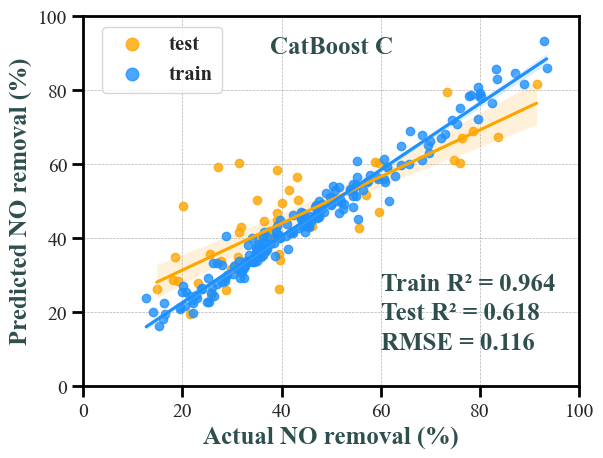

In [7]:
catboost = CatBoostRegressor(verbose=False)
train_pred, test_pred = process_regressor(catboost, x_train[C], x_test[C], y_train, y_test)
model_performance_metrics('Catboost Train', y_train, train_pred)
model_performance_metrics('Catboost Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "CatBoost C", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

cv train R2: 0.157 (+/- 0.218) 

Catboost Train mse: 0.00123 | rmse: 0.03513 | mae: 0.02750 | mape: 7.22671 | smape: 6.95624 | r2: 0.95971

Catboost Test mse: 0.01168 | rmse: 0.10809 | mae: 0.08123 | mape: 23.75120 | smape: 20.90611 | r2: 0.66735

测试图已保存：scatter_images1\CatBoost R.jpg


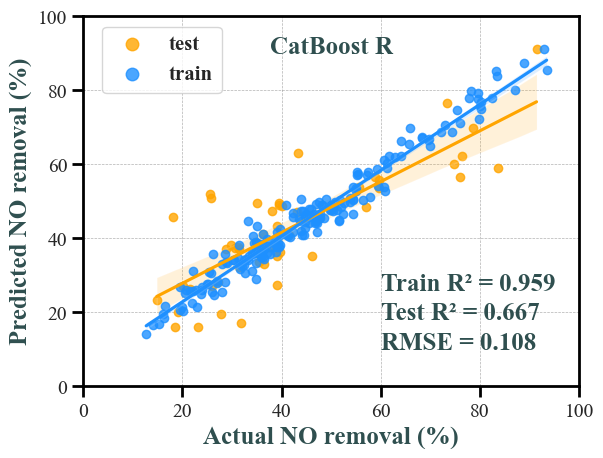

In [8]:
catboost = CatBoostRegressor(verbose=False)
train_pred, test_pred = process_regressor(catboost, x_train[R], x_test[R], y_train, y_test)
model_performance_metrics('Catboost Train', y_train, train_pred)
model_performance_metrics('Catboost Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "CatBoost R", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

cv train R2: 0.453 (+/- 0.096) 

Catboost Train mse: 0.00463 | rmse: 0.06806 | mae: 0.05075 | mape: 13.27676 | smape: 12.31692 | r2: 0.84877

Catboost Test mse: 0.01117 | rmse: 0.10568 | mae: 0.07866 | mape: 23.98043 | smape: 20.48135 | r2: 0.68207

测试图已保存：scatter_images1\CatBoost S.jpg


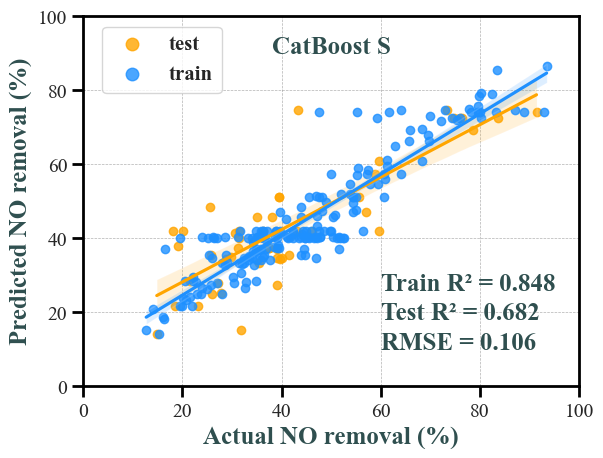

In [9]:
catboost = CatBoostRegressor(verbose=False)
train_pred, test_pred = process_regressor(catboost, x_train[S], x_test[S], y_train, y_test)
model_performance_metrics('Catboost Train', y_train, train_pred)
model_performance_metrics('Catboost Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "CatBoost S", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

cv train R2: 0.573 (+/- 0.048) 

Catboost Train mse: 0.00018 | rmse: 0.01337 | mae: 0.01049 | mape: 2.61889 | smape: 2.59154 | r2: 0.99416

Catboost Test mse: 0.00414 | rmse: 0.06437 | mae: 0.05232 | mape: 16.25182 | smape: 14.46584 | r2: 0.88204



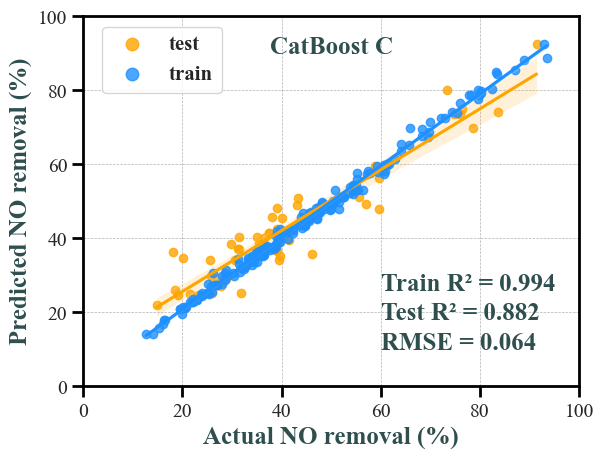

In [9]:
catboost = CatBoostRegressor(verbose=False)
train_pred, test_pred = process_regressor(catboost, x_train, x_test, y_train, y_test)
model_performance_metrics('Catboost Train', y_train, train_pred)
model_performance_metrics('Catboost Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "CatBoost C", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=False)